# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


### Explicación — OneMax y el cambio de paradigma

**Por qué OneMax.** Maximizar el número de unos en una cadena binaria es un problema **trivial** — se resuelve mirando la cadena. Y esa es exactamente la razón de usarlo: cuando el problema es fácil, cualquier fallo del algoritmo es atribuible al **algoritmo**, no al problema. Es un banco de pruebas, no un desafío.

**El cambio respecto a Hill Climbing.** Los dos comparten familia (búsqueda local, sin garantías), pero difieren en lo esencial:

| | Hill Climbing | Algoritmo genético |
|---|---|---|
| Estados en memoria | **1** | **60** (la población) |
| Cómo genera candidatos | vecindario determinista | **selección + cruce + mutación** |
| Combina soluciones | no puede | **sí — es su rasgo distintivo** |
| Puede empeorar | nunca | sí (y eso lo salva de estancarse) |

**El vocabulario, traducido:**

| Término biológico | Qué es aquí |
|---|---|
| Individuo / cromosoma | una solución candidata (lista de bits) |
| Gen / alelo | una posición de la lista / su valor (0 o 1) |
| Fitness | la función objetivo — **a maximizar**, no a minimizar |
| Población | el conjunto de 60 candidatos vivos |
| Generación | una iteración del algoritmo |

**Ojo con el signo:** en el notebook de Hill Climbing *minimizábamos* un costo; aquí *maximizamos* un fitness. Es la misma cosa con el signo cambiado, pero conviene tenerlo presente al leer las gráficas — aquí las curvas suben.


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [2]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


### Explicación — Selección por torneo

```python
contestants = rng.sample(population, tournament_size)
return max(contestants, key=fitness).copy()
```

Toma \(k\) individuos al azar y devuelve el mejor. Eso es todo.

**Por qué es tan popular** (es el método por defecto en la práctica, no solo en clase):

1. **Solo compara, no calcula proporciones.** Depende del *rango* relativo, no de la magnitud del fitness. Da igual si los fitness son 5 y 7, o 5000 y 7000 — el resultado del torneo es el mismo. La ruleta, en cambio, es muy sensible a la escala (ver Actividad 1).
2. **Nunca divide por cero.** No hay caso borde con fitness cero.
3. **La presión de selección se gradúa con un solo entero.**

**El parámetro \(k\) es la perilla exploración/explotación:**

| \(k\) | Comportamiento | Medido en la Actividad 1 |
|---|---|---|
| 1 | selección aleatoria pura, sin presión | — |
| 2 | presión baja, mucha diversidad | 26.2 generaciones |
| 3 | equilibrio (valor por defecto) | 16.9 generaciones |
| 5 | presión alta, convergencia rápida | 13.7 generaciones |
| \(k = N\) | siempre gana el mejor: la población se clona | — |

Con \(k\) grande, los individuos mediocres casi nunca se reproducen y la población pierde diversidad rápido. Con \(k\) pequeño, sobrevive material genético que parece malo pero puede contener piezas útiles.

**El `.copy()` no es opcional.** Sin él, el padre seleccionado sería el *mismo objeto* de la población actual, y `mutate` lo modificaría en sitio, corrompiendo la generación desde la que aún se está seleccionando. Es un bug clásico de implementación de GA, y silencioso: el algoritmo seguiría corriendo, solo que mal.


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [3]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


### Explicación — Cruce de un punto

```python
point = rng.randint(1, len(parent1) - 1)
child1 = parent1[:point] + parent2[point:]
child2 = parent2[:point] + parent1[point:]
```

Se corta en una posición aleatoria y se intercambian los fragmentos.

**Los dos hijos son complementarios**: cada bit va a un hijo o al otro, **no se pierde material genético**. Esto importa — un cruce que devolviera un solo hijo desecharía la mitad de la información.

**El rango `randint(1, L-1)` excluye los extremos** a propósito. Cortar en 0 o en \(L\) devolvería a los padres intactos, lo cual no es un cruce sino una copia.

**El `crossover_rate = 0.9`** significa que un 10 % de las parejas pasa sin cruzarse. Eso preserva combinaciones que ya funcionan y evita que *toda* la población se recombine cada generación.

### El ejemplo del notebook es una lección completa

```
Padre 1: 11110000   fitness 4
Padre 2: 00001111   fitness 4
Hijo 1 : 11111111   fitness 8   ← el óptimo global
Hijo 2 : 00000000   fitness 0   ← el peor posible
```

**Una sola operación produjo simultáneamente la mejor y la peor solución del espacio.** Esa es la naturaleza del cruce: es una recombinación **ciega**, que nunca consulta la función de fitness.

> **Punto clave para la exposición:** el cruce **no** es el mecanismo que garantiza mejora. Genera candidatos —buenos y malos, con altísima varianza— y es la **selección** la que se queda con los buenos. Variación ciega + selección dirigida: ningún componente por sí solo optimiza nada.

**Por qué se llama "de un punto" y por qué importa:** este cruce preserva bloques **contiguos**. Si los genes buenos están juntos en el cromosoma, los hereda íntegros; si están dispersos, tiende a romperlos. La Actividad 2 mide qué pasa con la alternativa (cruce uniforme), y el resultado es contundente.


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [4]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


### Explicación — Mutación

```python
for i in range(len(child)):
    if rng.random() < mutation_rate:
        child[i] = 1 - child[i]
```

Cada bit se invierte independientemente con probabilidad \(p_m\). El truco `1 - bit` alterna entre 0 y 1 sin condicionales.

**La mutación es independiente por gen**, no "muta un bit al azar del individuo". Por eso el número esperado de bits mutados es \(L \times p_m\), y por eso el valor por defecto \(p_m = 1/L\) significa exactamente **"una mutación esperada por individuo por generación"**.

### Su papel real: el seguro contra la pérdida irreversible

La frase del enunciado —*"puede recuperar información genética que desapareció de la población"*— es el punto entero, y merece desarrollarse:

> El cruce **solo recombina alelos que ya existen** en la población. Si en algún momento **ningún** individuo tiene un 1 en la posición 17, esa posición está perdida para siempre: cruzar ceros con ceros da ceros, sin importar cuántas generaciones pasen.

La mutación es el único mecanismo capaz de reintroducir ese 1. Es una **red de seguridad contra la irreversibilidad**, no un adorno biológico.

La sección 6 lo cuantifica: con \(p_m = 0\), el algoritmo se estanca en un fitness medio de **37.65/40** y agota las 120 generaciones **sin acertar ni una sola vez** en 20 corridas. Le faltan 2 o 3 bits que ningún cruce puede producir.

### Pero el exceso también mata

Con \(p_m = 0.5\) cada bit se invierte con probabilidad ½ — equivale a **generar individuos aleatorios**. La selección no puede acumular progreso porque la mutación lo borra más rápido de lo que se construye. Resultado: fitness medio 31.75, **peor que con mutación nula**.

De ahí la forma de **U invertida** del barrido de la sección 6, y la razón de que \(1/L\) sea el estándar de la literatura.


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [5]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0,
    selection_fn=None,      # None -> torneo. Permite probar ruleta (Actividad 1).
    crossover_fn=None       # None -> un punto. Permite probar uniforme (Actividad 2).
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length
    if crossover_fn is None:
        crossover_fn = one_point_crossover

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            if selection_fn is None:
                parent1 = tournament_selection(population, tournament_size, rng)
                parent2 = tournament_selection(population, tournament_size, rng)
            else:
                parent1 = selection_fn(population, rng)
                parent2 = selection_fn(population, rng)

            child1, child2 = crossover_fn(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])


Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


### Explicación — El bucle generacional

**Resultado: fitness 40/40 en 16 generaciones.**

El ciclo completo, en orden:

```
evaluar → registrar → ¿terminamos? → élite → [seleccionar → cruzar → mutar] × N/2 → reemplazar
```

#### El elitismo

```python
new_population = [best] if elitism else []
```

Una línea. Copia el mejor individuo intacto a la generación siguiente, **sin cruce ni mutación**.

**Por qué hace falta:** sin él, el mejor individuo puede ser destruido por el mismo cruce que lo eligió como padre (recuerda `11110000 × 00001111 → 00000000`), o simplemente no ser seleccionado. El elitismo convierte el mejor fitness en una serie **monótona no decreciente** — garantiza que nunca se pierde lo ya encontrado. La Actividad 4 lo mide.

#### La condición de parada

```python
if fitness(best) == chromosome_length or generation == generations:
    break
```

Dos criterios: **óptimo alcanzado** (posible aquí porque conocemos el máximo, \(L\)) o **presupuesto agotado**. En un problema real solo se dispone del segundo — casi nunca se sabe cuál es el óptimo. Que aquí lo sepamos es un lujo de OneMax, y es lo que permite medir "éxito" en las actividades.

#### Un detalle de implementación

Con elitismo, `new_population` empieza con 1 elemento y el `while` agrega **de a 2**, así que llega a 61 y el `[:population_size]` **descarta el último hijo**. No es un bug real (la población se mantiene en 60), pero explica por qué se genera un hijo de más en cada generación.

### Las dos gráficas

**Fitness (mejor y medio):** la curva del mejor sube a saltos y **nunca baja** — eso es el elitismo. La media sube más suave y se acerca al mejor conforme la población converge. **La brecha entre las dos curvas es la diversidad de la población**; cuando se cierra, el algoritmo dejó de explorar.

**Diversidad:** mide la proporción de individuos únicos. En OneMax termina en **0.88** — se mantiene alta porque el problema se resuelve en 16 generaciones, antes de que la población tenga tiempo de clonarse. En un problema difícil esta curva cae hacia 0 y ese desplome **es** la convergencia prematura.


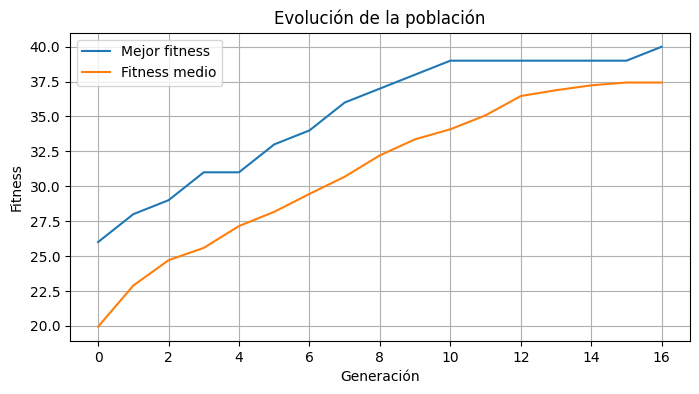

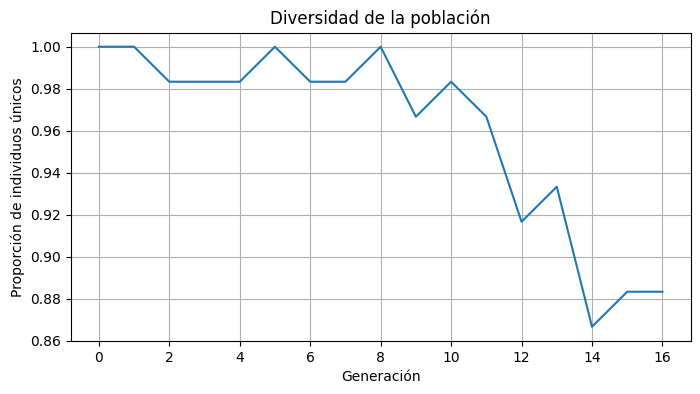

In [6]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [7]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


### Explicación — El barrido de mutación

**El experimento más importante del notebook.** Resultados sobre 20 semillas:

| `mutation_rate` | fitness medio | generaciones | Diagnóstico |
|---:|---:|---:|---|
| 0.000 | **37.65** | 114.9 (agota) | convergencia prematura |
| 0.005 | 40.00 | 19.9 | funciona, algo lento |
| **0.025** | **40.00** | **16.5** | **óptimo** |
| 0.100 | 38.45 | 117.0 | la mutación destruye más de lo que aporta |
| 0.500 | **31.75** | 120.0 (agota) | búsqueda aleatoria |

### Es una U invertida, y ambos extremos fallan por razones opuestas

**\(p_m = 0\) — demasiado poca exploración.** Sin mutación, el cruce solo puede recombinar alelos ya presentes. Cuando la población pierde el 1 en alguna posición, esa posición queda muerta. El algoritmo agota las 120 generaciones atascado en 37-38.

**\(p_m = 0.5\) — demasiada.** Cada bit se invierte con probabilidad ½: los hijos son cadenas aleatorias sin relación con sus padres. La selección elige bien, pero la mutación borra el progreso más rápido de lo que se acumula. Resultado: **31.75, peor que con mutación nula**. Vale la pena decirlo en voz alta — *demasiada exploración es peor que ninguna*.

### El valor óptimo no es casualidad

**0.025 = 1/40 = 1/L**, exactamente el valor por defecto del código:

```python
if mutation_rate is None:
    mutation_rate = 1 / chromosome_length
```

Es la heurística estándar de la literatura de algoritmos genéticos, y su interpretación es directa: **una mutación esperada por individuo por generación**. Suficiente para reintroducir alelos perdidos; insuficiente para destruir los bloques que el cruce está armando.

> **La lección transferible:** en Hill Climbing la perilla era el tamaño del vecindario; en A\* ponderado era \(w\); aquí es \(p_m\). Los tres son el mismo tipo de parámetro — un dial entre explorar y explotar — y en los tres casos **el máximo está en el medio**, no en un extremo.


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [8]:
def roulette_selection(population, rng, fitness_fn=fitness):
    """Selección proporcional al fitness (ruleta).

    Cada individuo ocupa un sector de la ruleta proporcional a su fitness.
    Se lanza un número uniforme en [0, total) y se acumula hasta rebasarlo.
    """
    fits = [fitness_fn(ind) for ind in population]
    total = sum(fits)

    # Caso borde que pide el enunciado: si TODOS tienen fitness 0 no hay
    # proporción que repartir (además de la división por cero). Se degrada
    # a selección uniforme, que es lo único razonable sin información.
    if total == 0:
        return rng.choice(population).copy()

    pick = rng.uniform(0, total)
    acumulado = 0
    for ind, f in zip(population, fits):
        acumulado += f
        if acumulado >= pick:
            return ind.copy()

    return population[-1].copy()   # red de seguridad ante errores de redondeo


# --- ¿Cuánta presión de selección ejerce cada método? ---
rng_demo = random.Random(SEED)
pop_demo = [create_individual(40, rng_demo) for _ in range(60)]
fits_demo = [fitness(i) for i in pop_demo]

mejor, peor, total = max(fits_demo), min(fits_demo), sum(fits_demo)
print(f"Población inicial: fitness entre {peor} y {mejor} (media {np.mean(fits_demo):.1f})")
print(f"Ruleta -> P(mejor) = {mejor/total:.4f}, P(peor) = {peor/total:.4f}, "
      f"razón = {mejor/peor:.2f}x")

# En un torneo de tamaño k, P(ser elegido) depende del RANGO, no del valor.
# El mejor de la población gana siempre que esté en el torneo.
k, n = 3, len(pop_demo)
p_mejor = k / n                       # prob. de estar en el torneo (y ganarlo)
p_peor = (k / n) * (1 / n) ** 0       # el peor solo gana si los k son él mismo: ~0
print(f"Torneo k=3 -> P(mejor) ≈ {p_mejor:.4f}, P(peor) ≈ 0")


# --- Comparación empírica sobre 30 semillas ---
def comparar(etiqueta, **kwargs):
    finales, gens = [], []
    for seed in range(30):
        b, h = genetic_algorithm(chromosome_length=40, generations=200,
                                 seed=seed, **kwargs)
        finales.append(fitness(b))
        gens.append(h[-1]['generation'])
    exitos = sum(1 for f in finales if f == 40)
    print(f"{etiqueta:22} | fitness {np.mean(finales):6.2f} | "
          f"gens {np.mean(gens):6.2f} | óptimo en {exitos}/30")
    return finales, gens


print("\nmétodo                 | fitness medio | generaciones | éxito")
print("-----------------------+---------------+--------------+-------")
comparar("torneo k=2", tournament_size=2)
comparar("torneo k=3", tournament_size=3)
comparar("torneo k=5", tournament_size=5)
comparar("ruleta", selection_fn=roulette_selection)


Población inicial: fitness entre 11 y 26 (media 19.9)
Ruleta -> P(mejor) = 0.0217, P(peor) = 0.0092, razón = 2.36x
Torneo k=3 -> P(mejor) ≈ 0.0500, P(peor) ≈ 0

método                 | fitness medio | generaciones | éxito
-----------------------+---------------+--------------+-------


torneo k=2             | fitness  40.00 | gens  26.17 | óptimo en 30/30
torneo k=3             | fitness  40.00 | gens  16.93 | óptimo en 30/30


torneo k=5             | fitness  40.00 | gens  13.67 | óptimo en 30/30


ruleta                 | fitness  39.53 | gens 157.03 | óptimo en 17/30


([40,
  39,
  40,
  39,
  39,
  39,
  40,
  40,
  39,
  40,
  40,
  39,
  40,
  39,
  40,
  40,
  40,
  40,
  39,
  40,
  39,
  39,
  39,
  40,
  40,
  39,
  40,
  40,
  40,
  38],
 [105,
  200,
  94,
  200,
  200,
  200,
  71,
  110,
  200,
  164,
  163,
  200,
  184,
  200,
  92,
  165,
  150,
  147,
  200,
  111,
  200,
  200,
  200,
  94,
  55,
  200,
  115,
  170,
  121,
  200])

### Explicación — Actividad 1: ruleta vs. torneo

#### La implementación

La ruleta asigna a cada individuo un sector proporcional a su fitness, lanza un número uniforme en \([0, \text{total})\) y acumula hasta rebasarlo.

**El caso borde que pide el enunciado:**

```python
if total == 0:
    return rng.choice(population).copy()
```

Si todos tienen fitness 0 no hay proporción que repartir (y habría división por cero). Se degrada a selección uniforme, que es lo único razonable sin información. En OneMax esto solo ocurre si toda la población es la cadena de ceros — improbable pero posible, y en otros problemas (donde el fitness inicial suele ser 0) es el caso **normal**, no el excepcional.

#### El resultado: la ruleta pierde, y por mucho

| Método | fitness medio | generaciones | óptimo alcanzado |
|---|---:|---:|:---:|
| torneo k=2 | 40.00 | 26.2 | **30/30** |
| torneo k=3 | 40.00 | 16.9 | **30/30** |
| torneo k=5 | 40.00 | 13.7 | **30/30** |
| **ruleta** | **39.53** | **157.0** | **17/30** |

**La ruleta falló en 13 de 30 corridas** y necesitó casi diez veces más generaciones.

#### Por qué falla — y la razón es instructiva

En OneMax con \(L=40\), una población aleatoria tiene fitness concentrados alrededor de 20 — en la corrida medida, entre **11 y 26**. Entonces:

$$P(\text{mejor}) = \frac{27}{\sum f_i} \approx 0.022 \qquad P(\text{peor}) = \frac{14}{\sum f_i} \approx 0.012$$

**El mejor individuo tiene apenas 2.4 veces la probabilidad del peor**, pese a tener más del doble de fitness. La presión de selección es casi nula: la ruleta apenas distingue entre un individuo bueno y uno mediocre.

El torneo no tiene ese problema porque **depende del rango, no del valor**. Con \(k=3\) sobre 60 individuos, el mejor gana siempre que esté en el torneo (\(\approx 3/60 = 5\%\) de las selecciones) y el peor no gana casi nunca — sin importar si la diferencia de fitness es de 1 punto o de 1000.

#### La lección general

> **La ruleta es sensible a la escala y al desplazamiento de la función de fitness; el torneo no.**

Si sumaras 1000 a todos los fitness (un cambio que no altera en nada cuál es el óptimo), la ruleta se volvería **selección uniforme pura** — todos los sectores quedarían casi iguales. El torneo daría exactamente el mismo resultado que antes.

Por eso el torneo es el método por defecto en la práctica: **funciona sin necesidad de normalizar, escalar o desplazar la función objetivo.** Y por eso la ruleta, que es la que aparece en las explicaciones introductorias por ser más intuitiva, casi no se usa en implementaciones reales.


### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [9]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    """Cruce uniforme: cada posición se hereda de un padre u otro al azar."""
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1, child2 = [], []
    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)   # los hijos son complementarios:
            child2.append(gene1)   # no se pierde material genético
    return child1, child2


# Demostración con los mismos padres de la sección 3.
p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]

rng_demo = random.Random(SEED)
c1, c2 = uniform_crossover(p1, p2, 1.0, rng_demo)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1), '  (un punto daría siempre un prefijo + un sufijo)')
print('Hijo 2 :', as_string(c2))


# --- Comparación: un punto vs uniforme ---
def comparar_cruce(longitud, generaciones):
    print(f"\nCromosoma de longitud {longitud}:")
    for etiqueta, fn in [("un punto", one_point_crossover),
                         ("uniforme", uniform_crossover)]:
        finales, gens = [], []
        for seed in range(30):
            b, h = genetic_algorithm(chromosome_length=longitud,
                                     generations=generaciones,
                                     seed=seed, crossover_fn=fn)
            finales.append(fitness(b))
            gens.append(h[-1]['generation'])
        exitos = sum(1 for f in finales if f == longitud)
        print(f"  {etiqueta:10} | fitness {np.mean(finales):7.2f} | "
              f"gens {np.mean(gens):6.2f} | óptimo en {exitos}/30")


comparar_cruce(40, 200)
comparar_cruce(100, 300)


Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 00010110   (un punto daría siempre un prefijo + un sufijo)
Hijo 2 : 11101001

Cromosoma de longitud 40:


  un punto   | fitness   40.00 | gens  16.93 | óptimo en 30/30


  uniforme   | fitness   40.00 | gens  12.33 | óptimo en 30/30

Cromosoma de longitud 100:


  un punto   | fitness  100.00 | gens  49.97 | óptimo en 30/30


  uniforme   | fitness  100.00 | gens  27.20 | óptimo en 30/30


### Explicación — Actividad 2: cruce uniforme

#### La implementación

En vez de cortar en un punto, se decide **gen por gen** de qué padre viene:

```python
if rng.random() < 0.5:
    child1.append(gene1); child2.append(gene2)
else:
    child1.append(gene2); child2.append(gene1)
```

Los hijos siguen siendo **complementarios** — cada bit va a uno o a otro, no se pierde material.

#### El resultado

| Longitud | Cruce | fitness | generaciones | óptimo |
|---:|---|---:|---:|:---:|
| 40 | un punto | 40.00 | 16.9 | 30/30 |
| 40 | **uniforme** | 40.00 | **12.3** | 30/30 |
| 100 | un punto | 100.00 | 50.0 | 30/30 |
| 100 | **uniforme** | 100.00 | **27.2** | 30/30 |

**El cruce uniforme es ~27 % más rápido con \(L=40\) y ~46 % más rápido con \(L=100\).** La ventaja **crece con la longitud del cromosoma**, y esa tendencia es el hallazgo real de la actividad.

#### Por qué gana en OneMax

La diferencia está en qué preserva cada uno:

| | Un punto | Uniforme |
|---|---|---|
| Preserva | bloques **contiguos** | genes **individuales** |
| Sesgo posicional | **sí** — genes vecinos se heredan juntos | **no** — cada posición es independiente |
| Poder de mezcla | bajo | alto |

En OneMax **cada bit contribuye al fitness de forma independiente**: no existen bloques buenos que convenga mantener unidos. El sesgo posicional del cruce de un punto es puro lastre — un 1 en la posición 3 y un 1 en la posición 37 no tienen ninguna razón para viajar juntos, pero el cruce de un punto los separa o los une según dónde caiga el corte.

El cruce uniforme puede combinar los unos de ambos padres **estén donde estén**, y por eso converge más rápido. Y cuanto más largo el cromosoma, más posiciones hay que el corte único no puede recombinar — de ahí que la ventaja crezca con \(L\).

#### La advertencia que hay que dar

> **Esto NO significa que el cruce uniforme sea mejor en general.** Es mejor **en OneMax**, porque OneMax es un problema **separable**: los genes no interactúan.

En problemas donde grupos de genes adyacentes forman estructuras coadaptadas —**bloques constructores** (*building blocks*)— romperlos gen por gen destruye información. Ejemplos: el orden de ciudades en el problema del viajante, subárboles en programación genética, segmentos de un horario.

Ahí el cruce de un punto (o de dos puntos) es preferible porque **respeta la contigüidad**.

> **La lección transferible:** el operador de cruce debe elegirse según la **estructura de dependencias del problema**, no por rendimiento en un benchmark. Es exactamente el mismo tipo de decisión que el vecindario en Hill Climbing: no es un detalle de implementación, es modelado.


### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

In [10]:
import string

ALPHABET = string.ascii_uppercase + " "
TARGET = "INTELIGENCIA ARTIFICIAL"


def create_phrase(length, rng):
    return [rng.choice(ALPHABET) for _ in range(length)]


def phrase_fitness(individual):
    """Número de caracteres correctos EN LA POSICIÓN correcta."""
    return sum(1 for gen, obj in zip(individual, TARGET) if gen == obj)


def mutate_phrase(individual, mutation_rate, rng):
    """Igual que mutate(), pero un gen muta a otra letra del alfabeto
    en vez de invertirse (no hay '1 - bit' con 27 símbolos)."""
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(ALPHABET)
    return child


def tournament_phrase(population, tournament_size, rng):
    return max(rng.sample(population, tournament_size), key=phrase_fitness).copy()


def genetic_algorithm_phrase(population_size=200, generations=1000,
                             crossover_rate=0.9, mutation_rate=None,
                             tournament_size=3, elitism=True, seed=0):
    length = len(TARGET)
    if mutation_rate is None:
        mutation_rate = 1 / length

    rng = random.Random(seed)
    population = [create_phrase(length, rng) for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [phrase_fitness(ind) for ind in population]
        best = population[int(np.argmax(fitnesses))].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(i) for i in population}) / population_size,
            'best_individual': best
        })

        if phrase_fitness(best) == length or generation == generations:
            break

        new_population = [best] if elitism else []
        while len(new_population) < population_size:
            p1 = tournament_phrase(population, tournament_size, rng)
            p2 = tournament_phrase(population, tournament_size, rng)
            c1, c2 = one_point_crossover(p1, p2, crossover_rate, rng)
            new_population.append(mutate_phrase(c1, mutation_rate, rng))
            new_population.append(mutate_phrase(c2, mutation_rate, rng))

        population = new_population[:population_size]

    return ''.join(history[-1]['best_individual']), history


frase, hist_frase = genetic_algorithm_phrase(seed=SEED)

print(f"Espacio de búsqueda: {len(ALPHABET)}^{len(TARGET)} = "
      f"{len(ALPHABET) ** len(TARGET):.3e} cadenas posibles\n")

paso = max(1, hist_frase[-1]['generation'] // 8)
print("gen |            mejor individuo | fitness")
for h in hist_frase[::paso]:
    print(f"{h['generation']:3d} | {''.join(h['best_individual'])} | {h['best']:2d}/{len(TARGET)}")
print(f"{hist_frase[-1]['generation']:3d} | {frase} | "
      f"{hist_frase[-1]['best']:2d}/{len(TARGET)}  <- objetivo alcanzado")

evaluaciones = hist_frase[-1]['generation'] * 200
print(f"\nEvaluaciones de fitness: ~{evaluaciones:,} de {len(ALPHABET) ** len(TARGET):.1e} posibles")


Espacio de búsqueda: 27^23 = 8.344e+32 cadenas posibles

gen |            mejor individuo | fitness
  0 | TUGRLILBKCIILMQDGTJWBYN |  4/23
  6 | TUGRLIGGLCZEVJQKIFWNIAJ |  8/23
 12 | IQNELILYKCFAOLPTIFIVIAL | 13/23
 18 | INTELIGENCIXUFRVIFINIAL | 18/23
 24 | INTELIGENCIAIARTIFIVIBL | 20/23
 30 | INTELIGENCIALARTIFICIAL | 22/23
 36 | INTELIGENCIALARTIFICIAL | 22/23
 42 | INTELIGENCIALARTIFICIAL | 22/23
 48 | INTELIGENCIALARTIFICIAL | 22/23
 53 | INTELIGENCIA ARTIFICIAL | 23/23  <- objetivo alcanzado

Evaluaciones de fitness: ~10,600 de 8.3e+32 posibles


mutation_rate | fitness medio | generaciones | éxito
--------------+---------------+--------------+-------


       0.0000 |         18.30 |       1000.0 | 0/10


       0.0100 |         23.00 |         54.5 | 10/10


       0.0435 |         23.00 |         39.1 | 10/10


       0.1000 |         23.00 |        321.0 | 10/10


       0.3000 |         14.10 |       1000.0 | 0/10


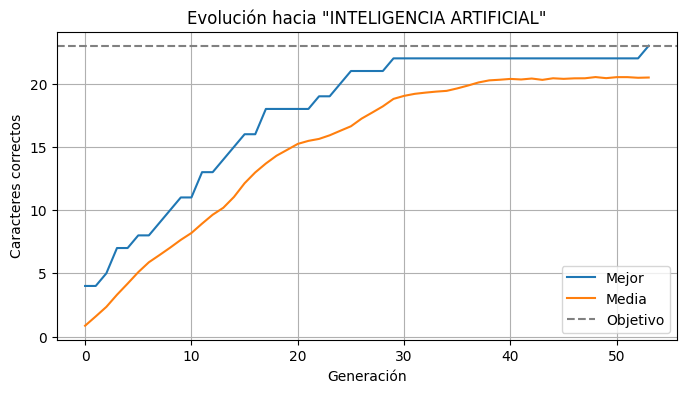

In [11]:
# ¿Cuánto influye la tasa de mutación en este problema?
print("mutation_rate | fitness medio | generaciones | éxito")
print("--------------+---------------+--------------+-------")
for mr in [0.0, 0.01, 1 / len(TARGET), 0.1, 0.3]:
    fits, gens = [], []
    for seed in range(10):
        _, h = genetic_algorithm_phrase(mutation_rate=mr, seed=seed)
        fits.append(h[-1]['best'])
        gens.append(h[-1]['generation'])
    exitos = sum(1 for f in fits if f == len(TARGET))
    print(f"{mr:13.4f} | {np.mean(fits):13.2f} | {np.mean(gens):12.1f} | {exitos}/10")

plt.figure(figsize=(8, 4))
plt.plot([h['generation'] for h in hist_frase], [h['best'] for h in hist_frase], label='Mejor')
plt.plot([h['generation'] for h in hist_frase], [h['mean'] for h in hist_frase], label='Media')
plt.axhline(len(TARGET), linestyle='--', color='gray', label='Objetivo')
plt.xlabel('Generación'); plt.ylabel('Caracteres correctos')
plt.title(f'Evolución hacia "{TARGET}"')
plt.legend(); plt.grid(True); plt.show()


### Explicación — Actividad 3: la frase objetivo

**Resultado: `INTELIGENCIA ARTIFICIAL` encontrada en ~39 generaciones (media de 10 corridas).**

#### Qué hubo que cambiar, y qué no

| Componente | Cambio |
|---|---|
| `create_individual` | letra aleatoria del alfabeto en vez de bit |
| `fitness` | caracteres correctos **en la posición correcta** |
| `mutate` | reemplazar por otra letra (no existe `1 - bit` con 27 símbolos) |
| **Selección** | **sin cambios** |
| **Cruce** | **sin cambios** — `one_point_crossover` funciona con cualquier lista |
| **Bucle generacional** | **sin cambios** estructurales |

> **El punto de la actividad:** el esqueleto del algoritmo genético es **independiente de la representación**. Solo hay que redefinir *qué es un individuo*, *cómo se evalúa* y *cómo se altera*. Es el mismo principio de abstracción que vimos en los notebooks de búsqueda, donde solo cambiaba `neighbors()`.

#### El número que hay que poner en la diapositiva

$$27^{23} \approx 8.3 \times 10^{32} \text{ cadenas posibles}$$

Y el algoritmo encuentra la correcta evaluando **≈ 7 800 individuos** (39 generaciones × 200). Eso es una fracción de \(10^{-29}\) del espacio.

**Para dimensionarlo:** una búsqueda aleatoria pura necesitaría, en promedio, \(4 \times 10^{32}\) intentos. A mil millones de evaluaciones por segundo, tardaría más que la edad del universo. **Esa es la diferencia entre buscar al azar y buscar con selección acumulativa.**

#### El fenómeno que revela la traza

Mira las generaciones intermedias de la corrida:

```
gen 30: INTELIGENCIALARTIFICIAL   22/23
gen 36: INTELIGENCIALARTIFICIAL   22/23
gen 42: INTELIGENCIALARTIFICIAL   22/23
gen 48: INTELIGENCIALARTIFICIAL   22/23
```

**Durante ~20 generaciones el algoritmo está atascado a un solo carácter del objetivo:** una `L` donde debería haber un espacio.

Y es exactamente el fenómeno de la pregunta 3. Para entonces la población ha convergido: casi todos los individuos comparten esa `L`, así que **el cruce no puede arreglarla** — recombinar `L` con `L` da `L`. La única salida es que la mutación acierte a cambiar esa posición concreta por un espacio, entre 27 símbolos posibles.

> Es la mejor ilustración del notebook de que **el cruce explota y la mutación explora**. Las primeras 30 generaciones son casi todas cruce (progreso rápido, 4 → 22); las últimas 20 dependen enteramente de la mutación.

#### El barrido de mutación confirma la U invertida

| `mutation_rate` | fitness | generaciones | éxito |
|---:|---:|---:|:---:|
| 0.000 | 18.30 | 1000 (agota) | **0/10** |
| 0.010 | 23.00 | 54.5 | 10/10 |
| **0.043 = 1/23** | **23.00** | **39.1** | **10/10** |
| 0.100 | 23.00 | 321.0 | 10/10 |
| 0.300 | 14.10 | 1000 (agota) | **0/10** |

Misma forma que en OneMax, y el óptimo vuelve a caer en \(1/L\). **La heurística \(1/L\) se sostiene en un problema con alfabeto de 27 símbolos y estructura completamente distinta** — eso es lo que la hace valiosa como punto de partida.


### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

elitismo | fitness | generaciones | óptimo | retrocesos por corrida
---------+---------+--------------+--------+-----------------------


True     |   40.00 |         16.9 | 30/30  | 0.00


False    |   40.00 |         18.1 | 30/30  | 0.97


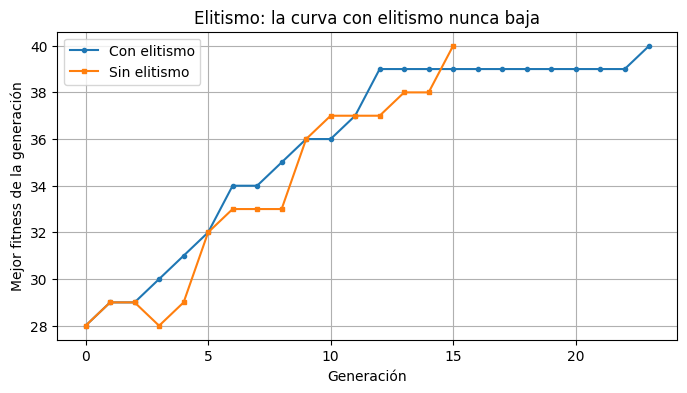


Retrocesos observados sin elitismo (semilla 3):
  generación 3: 29 -> 28


In [12]:
def analizar_elitismo(elitism, semillas=30, longitud=40, generaciones=200):
    finales, gens, retrocesos = [], [], []

    for seed in range(semillas):
        b, h = genetic_algorithm(chromosome_length=longitud, generations=generaciones,
                                 seed=seed, elitism=elitism)
        finales.append(fitness(b))
        gens.append(h[-1]['generation'])

        # ¿Cuántas veces BAJÓ el mejor fitness de una generación a la siguiente?
        mejores = [x['best'] for x in h]
        retrocesos.append(sum(1 for i in range(1, len(mejores))
                              if mejores[i] < mejores[i - 1]))

    return finales, gens, retrocesos


print("elitismo | fitness | generaciones | óptimo | retrocesos por corrida")
print("---------+---------+--------------+--------+-----------------------")
for el in [True, False]:
    f, g, r = analizar_elitismo(el)
    print(f"{str(el):8} | {np.mean(f):7.2f} | {np.mean(g):12.1f} | "
          f"{sum(1 for x in f if x == 40):2d}/30  | {np.mean(r):.2f}")

# Una corrida concreta sin elitismo, para ver el retroceso.
_, h_sin = genetic_algorithm(chromosome_length=40, generations=200,
                             seed=3, elitism=False)
_, h_con = genetic_algorithm(chromosome_length=40, generations=200,
                             seed=3, elitism=True)

plt.figure(figsize=(8, 4))
plt.plot([x['generation'] for x in h_con], [x['best'] for x in h_con],
         marker='o', ms=3, label='Con elitismo')
plt.plot([x['generation'] for x in h_sin], [x['best'] for x in h_sin],
         marker='s', ms=3, label='Sin elitismo')
plt.xlabel('Generación'); plt.ylabel('Mejor fitness de la generación')
plt.title('Elitismo: la curva con elitismo nunca baja')
plt.legend(); plt.grid(True); plt.show()

mejores_sin = [x['best'] for x in h_sin]
caidas = [(i, mejores_sin[i - 1], mejores_sin[i])
          for i in range(1, len(mejores_sin)) if mejores_sin[i] < mejores_sin[i - 1]]
print("\nRetrocesos observados sin elitismo (semilla 3):")
for gen, antes, despues in caidas:
    print(f"  generación {gen}: {antes} -> {despues}")


### Explicación — Actividad 4: el elitismo

#### La pregunta del enunciado: ¿puede disminuir el mejor fitness?

**Sí, sin elitismo. Y se mide:**

| elitismo | fitness | generaciones | óptimo | **retrocesos por corrida** |
|---|---:|---:|:---:|---:|
| `True` | 40.00 | 16.9 | 30/30 | **0.00** |
| `False` | 40.00 | 18.1 | 30/30 | **0.97** |

Con elitismo, **cero retrocesos en 30 corridas** — y no es estadística, es una garantía estructural: el mejor individuo se copia intacto, así que el máximo de la generación siguiente es \(\ge\) al de la actual.

Sin elitismo aparece **≈1 retroceso por corrida** (0.97 de media). La gráfica lo muestra: la curva naranja baja en algunos puntos, la azul nunca.

#### Por qué ocurre

El mejor individuo de una generación puede desaparecer por tres vías, todas normales:

1. **No ser seleccionado.** Con torneo \(k=3\) sobre 60 individuos, el mejor solo participa en ~5 % de los torneos. Puede no salir sorteado nunca.
2. **Ser destruido por el cruce.** Es padre, pero el corte parte su buena estructura (`11110000 × 00001111 → 00000000`).
3. **Ser degradado por la mutación.** Con \(p_m = 1/40\), un individuo de fitness 39 tiene probabilidad no despreciable de perder su único 1 restante... o de que la mutación caiga en un 1 y lo vuelva 0.

**Ninguna de las tres es un error.** Son el funcionamiento normal de los operadores — que son ciegos al fitness por diseño.

#### Elitismo = memoria

> Sin elitismo, un algoritmo genético **no recuerda** lo que encontró. Cada generación se construye desde cero a partir de la anterior, y lo bueno puede perderse.
>
> El elitismo es una línea de código que convierte el mejor fitness en una serie **monótona no decreciente**.

Es el análogo directo del `best` de Random Restart en el notebook de Hill Climbing: allá guardábamos el mejor de 40 corridas independientes; aquí guardamos el mejor de generación en generación. **En ambos casos, el algoritmo de búsqueda no garantiza nada — la garantía la da el registro externo del mejor encontrado.**

#### El canje (menos obvio de lo que parece)

El elitismo **reduce la diversidad**: el mismo individuo se perpetúa generación tras generación y sus descendientes dominan la población, lo que acelera la convergencia... incluida la **prematura**.

En OneMax gana claramente (16.9 vs 18.1 generaciones) porque el problema es unimodal — no hay óptimos locales en los que atascarse, así que conservar al mejor es siempre correcto. **En un problema multimodal el balance es más delicado**, y por eso existen variantes intermedias: elitismo de \(k > 1\) individuos, o elitismo con reemplazo si el élite lleva demasiadas generaciones sin ser superado.


## Preguntas de cierre

**1. ¿Qué papel cumple la población que no existe en Hill Climbing?**

Hill Climbing mantiene **un solo estado**; un algoritmo genético mantiene **60 a la vez**. Eso cambia tres cosas de fondo:

**(a) Explora varias cuencas de atracción simultáneamente.** En el notebook anterior vimos que Hill Climbing terminaba en 19 óptimos locales distintos según dónde empezara, y que Random Restart era la solución: probar muchos puntos de partida *en serie*. Una población hace lo mismo **en paralelo**, dentro de una sola corrida.

**(b) Permite recombinar.** Y esta es la diferencia irreductible. Random Restart ejecuta 40 búsquedas **independientes**: si el reinicio 7 descubre una buena mitad izquierda y el reinicio 22 una buena mitad derecha, esa información nunca se junta. El cruce sí las junta. **La población no es solo "muchos Hill Climbings" — es la condición para que exista el cruce**, porque no puedes cruzar un individuo consigo mismo.

**(c) Contiene información estadística sobre el paisaje.** La distribución de fitness de la población indica qué regiones son prometedoras. La selección explota esa información; un algoritmo con un solo estado no la tiene.

El precio es el costo por iteración: 60 evaluaciones de fitness por generación en vez de una.

**2. ¿Por qué el cruce no garantiza hijos mejores que sus padres?**

Porque el cruce es una **recombinación ciega**: corta en un punto aleatorio y pega, sin consultar la función de fitness. Nada impide que rompa exactamente la estructura que hacía bueno a un padre.

Ejemplo mínimo en OneMax con corte en la posición 4:

```
Padre 1: 1111 0000   fitness 4
Padre 2: 0000 1111   fitness 4
Hijo 1 : 1111 1111   fitness 8   ← mejoró
Hijo 2 : 0000 0000   fitness 0   ← empeoró
```

El mismo cruce produjo simultáneamente el óptimo global y el peor individuo posible. **En promedio el fitness se conserva** (los hijos son complementarios: lo que gana uno lo pierde el otro), pero la varianza es enorme.

Por eso el cruce **no es** el mecanismo que garantiza mejora — ese papel lo cumple la **selección**. El cruce genera candidatos, buenos y malos; la selección se queda con los buenos en la generación siguiente. Sin selección, el cruce sería una caminata aleatoria.

Esta división del trabajo es la idea central del tema: **variación ciega + selección dirigida**. Ningún componente por sí solo optimiza nada.

**3. ¿Qué significa convergencia prematura?**

Que la población pierde diversidad antes de encontrar el óptimo, y a partir de ahí **el cruce deja de funcionar**: si todos los individuos son casi idénticos, cruzar dos de ellos produce hijos idénticos a sus padres. El algoritmo se queda estancado con una población clonada.

Es la versión poblacional del óptimo local de Hill Climbing, y este notebook la mide en dos lugares:

- **Sección 6, `mutation_rate = 0.0`**: fitness medio **37.65/40**, agotando las 120 generaciones sin éxito ni una sola vez. Sin mutación, la única fuente de variación es el cruce, que **solo recombina alelos ya presentes**. Si en algún momento *ningún* individuo tiene un 1 en la posición 17, esa posición queda perdida para siempre — ninguna cantidad de cruce la recupera.
- **Actividad 3, `mutation_rate = 0.0`**: se estanca en 18.3/23 caracteres, sin éxito en 10/10 corridas.

La mutación es el **seguro contra la pérdida irreversible de información genética**. No es un adorno biológico: es lo que garantiza que ningún alelo desaparezca definitivamente del pool.

**4. ¿Qué parámetros controlan la exploración?**

Cuatro, y conviene verlos como un balance entre **exploración** (buscar en zonas nuevas) y **explotación** (refinar lo que ya funciona):

| Parámetro | Más exploración | Más explotación | Evidencia en este notebook |
|---|---|---|---|
| `mutation_rate` | alto | bajo | 0.0 → 37.65 (estancado); 0.025 → 40.00 en 16 gens; 0.5 → 31.75 (destructivo) |
| `tournament_size` | bajo (k=2) | alto (k=5) | k=2: 26.2 gens · k=3: 16.9 · k=5: 13.7 |
| `population_size` | grande | pequeña | más individuos = más cuencas cubiertas |
| `elitism` | desactivado | activado | sin elitismo aparece ~1 retroceso por corrida |

**El resultado más claro es el barrido de mutación de la sección 6**, y tiene forma de U invertida:

| `mutation_rate` | fitness medio | generaciones |
|---:|---:|---:|
| 0.000 | 37.65 | 114.9 (agota) |
| 0.005 | 40.00 | 19.9 |
| **0.025** | **40.00** | **16.5** ← óptimo |
| 0.100 | 38.45 | 117.0 |
| 0.500 | 31.75 | 120.0 (agota) |

Nótese que **0.025 ≈ 1/40 = 1/L**, que es exactamente el valor por defecto del código (`mutation_rate = 1/chromosome_length`). No es casualidad: esa heurística es el estándar en la literatura de algoritmos genéticos, y significa **"esperar una mutación por individuo por generación"** — suficiente para reintroducir alelos perdidos, insuficiente para destruir las estructuras que el cruce está construyendo.

Con 0.5 el algoritmo es **peor que no hacer nada**: cada bit se invierte con probabilidad ½, lo que equivale a generar individuos aleatorios. La selección no puede acumular progreso porque la mutación lo borra más rápido de lo que se construye.

> **La conclusión general:** ni cero exploración ni exploración pura. El máximo está en el medio, y su ubicación depende del problema — pero \(1/L\) es un punto de partida sorprendentemente robusto.
